In [1]:
import pandas as pd
import numpy as np
import sklearn
sklearn.set_config(transform_output="pandas")
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, loguniform
import warnings
warnings.filterwarnings('ignore')

In [2]:
rental = pd.read_csv('./data/data.csv')
rental.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,250.0
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,1280.0


In [3]:
rental_copy = rental.copy()

In [4]:
rental_copy = rental_copy.dropna(subset=['rent'])

In [5]:
rental_copy = rental_copy.drop(columns=['Offer','URL'])

In [6]:
rental_copy['has_maid'] = rental_copy['Beds'].str.contains('Maid', case=False, na=False).astype(int)

In [7]:
rental_copy['Beds'] = rental_copy['Beds'].str.replace('Maid','',case=False)
rental_copy['Beds'] = rental_copy['Beds'].str.replace('+','',case=False)
rental_copy['Beds'] = rental_copy['Beds'].str.strip()
rental_copy['Beds'] = rental_copy['Beds'].replace('studio', '0')
rental_copy['Beds'] = pd.to_numeric(rental_copy['Beds'])

In [8]:
rental_copy['Baths'] = rental_copy['Baths'].str.replace('+','')
rental_copy['Baths'] = rental_copy['Baths'].replace('none', np.nan)
rental_copy['Baths'] = pd.to_numeric(rental_copy['Baths'])

In [9]:
rental_copy = rental_copy.dropna(subset=['Baths'])

In [10]:
rental_copy['Size_sqm'] = rental_copy['Size'].str.split('/').str[-1]
rental_copy['Size_sqm'] = rental_copy['Size_sqm'].str.replace('sqm', '', case=False)
rental_copy['Size_sqm'] = rental_copy['Size_sqm'].str.replace(',', '')
rental_copy['Size_sqm'] = pd.to_numeric(rental_copy['Size_sqm'], errors='coerce')
rental_copy = rental_copy.drop(columns=['Size'])

In [11]:
rental_copy['is_inclusive'] = (rental_copy['Include_w_e'] == 'Inclusive').astype(int)
rental_copy = rental_copy.drop(columns=['Include_w_e'])

In [12]:
rental_copy.info()

<class 'pandas.DataFrame'>
Index: 10574 entries, 0 to 10577
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10574 non-null  int64  
 1   Property_type      10574 non-null  str    
 2   Title              10574 non-null  str    
 3   Area               10574 non-null  str    
 4   Governorate        10574 non-null  str    
 5   Beds               10574 non-null  int64  
 6   Baths              10574 non-null  float64
 7   Availability_date  10058 non-null  str    
 8   Agent_name         10574 non-null  str    
 9   Agency             10574 non-null  str    
 10  Amenities          10269 non-null  float64
 11  rent               10574 non-null  float64
 12  has_maid           10574 non-null  int64  
 13  Size_sqm           10574 non-null  int64  
 14  is_inclusive       10574 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 2.6 MB


In [13]:
rental_copy.describe()

,Property_id,Beds,Baths,Amenities,rent,has_maid,Size_sqm,is_inclusive
count,10574.000000,10574.000000,10574.000000,10269.000000,10574.000000,10574.000000,10574.000000,10574.000000
mean,7060.277284,2.202478,2.663703,10.321258,718.784944,0.210800,171.275392,0.612446
std,4080.050950,1.206382,1.290132,5.093565,5318.277795,0.407896,204.971659,0.487215
min,2.000000,0.000000,1.000000,1.000000,50.000000,0.000000,1.000000,0.000000
25%,3522.500000,1.000000,2.000000,6.000000,330.000000,0.000000,90.000000,0.000000
50%,7023.500000,2.000000,2.000000,11.000000,450.000000,0.000000,125.000000,1.000000
75%,10605.750000,3.000000,3.000000,14.000000,700.000000,0.000000,180.000000,1.000000
max,14103.000000,7.000000,7.000000,25.000000,400000.000000,1.000000,13742.000000,1.000000


In [14]:
rental_copy['Title'] = rental_copy['Title'].fillna('')
title_lower = rental_copy['Title'].str.lower()

rental_copy['is_furnished'] = title_lower.str.contains('furnish', na=False).astype(int)
rental_copy['is_luxury']    = title_lower.str.contains('luxury|luxurious', na=False).astype(int)
rental_copy['has_pool']     = title_lower.str.contains('pool', na=False).astype(int)
rental_copy['has_sea_view'] = title_lower.str.contains('sea view|sea-view|seaview', na=False).astype(int)
rental_copy['is_spacious']  = title_lower.str.contains('spacious|large', na=False).astype(int)
rental_copy['is_standalone'] = title_lower.str.contains('standalone', na=False).astype(int)
rental_copy['is_private']   = title_lower.str.contains('private|pvt', na=False).astype(int)
rental_copy['has_garden']   = title_lower.str.contains('garden', na=False).astype(int)
rental_copy['is_compound']  = title_lower.str.contains('compound', na=False).astype(int)
rental_copy['has_maids']    = title_lower.str.contains('maids|maid', na=False).astype(int)
rental_copy['is_approved']  = title_lower.str.contains('approved|navy', na=False).astype(int)

rental_copy = rental_copy.drop(columns=['Title'])

In [15]:
rental_copy

,Property_id,Property_type,Area,Governorate,Beds,Baths,Availability_date,Agent_name,Agency,Amenities,...,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
0,6046,Villa,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3,4.0,9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,...,1,0,0,0,0,0,0,0,0,0
1,2240,Villa,Diyar Al Muharraq,Muharraq Governorate,5,6.0,16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,...,1,0,0,0,0,0,0,0,0,0
2,6248,Apartment,Al Juffair,Capital Governorate,0,1.0,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,...,0,0,0,0,0,0,0,0,0,0
3,7177,Apartment,Jidhafs,Northern Governorate,3,3.0,6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,...,0,0,0,0,0,0,0,0,0,0
4,7842,Villa,Al Juffair,Capital Governorate,5,5.0,30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,...,0,1,0,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10573,5192,Apartment,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,2,3.0,29 Aug 2025,Al Ward Real Estate,AlWard Real Estate,17.0,...,0,0,0,0,0,0,0,0,1,0
10574,13419,Apartment,Al Juffair,Capital Governorate,2,2.0,NaN,Muhammad,Al Waleed Homes,8.0,...,0,0,0,0,0,0,0,0,0,0
10575,5391,Apartment,Seef,Capital Governorate,1,2.0,27 Aug 2025,Bilal Mohamed,River West Properties,11.0,...,0,0,1,0,0,0,0,0,0,0
10576,861,Villa,"Zinj, Manama",Capital Governorate,3,4.0,24 Sep 2025,Shaji Kottathazham,AIM REAL ESTATE,11.0,...,0,1,0,0,1,1,1,0,0,0


In [16]:
rental_copy.isnull().sum()

Property_id            0
Property_type          0
Area                   0
Governorate            0
Beds                   0
Baths                  0
Availability_date    516
Agent_name             0
Agency                 0
Amenities            305
rent                   0
has_maid               0
Size_sqm               0
is_inclusive           0
is_furnished           0
is_luxury              0
has_pool               0
has_sea_view           0
is_spacious            0
is_standalone          0
is_private             0
has_garden             0
is_compound            0
has_maids              0
is_approved            0
dtype: int64

In [17]:
rental_copy = rental_copy.drop(columns=['Availability_date'])

In [18]:
rental_copy['Amenities'] = rental_copy['Amenities'].fillna(rental_copy['Amenities'].median())
print("Amenities nulls:", rental_copy['Amenities'].isnull().sum())

Amenities nulls: 0


In [19]:
rental_copy.isnull().sum()

Property_id      0
Property_type    0
Area             0
Governorate      0
Beds             0
Baths            0
Agent_name       0
Agency           0
Amenities        0
rent             0
has_maid         0
Size_sqm         0
is_inclusive     0
is_furnished     0
is_luxury        0
has_pool         0
has_sea_view     0
is_spacious      0
is_standalone    0
is_private       0
has_garden       0
is_compound      0
has_maids        0
is_approved      0
dtype: int64

In [20]:
rental_copy.describe()

,Property_id,Beds,Baths,Amenities,rent,has_maid,Size_sqm,is_inclusive,is_furnished,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
count,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000,10574.000000
mean,7060.277284,2.202478,2.663703,10.340836,718.784944,0.210800,171.275392,0.612446,0.186401,0.153679,0.132306,0.139777,0.188197,0.004918,0.073766,0.063174,0.034140,0.056176,0.028939
std,4080.050950,1.206382,1.290132,5.020846,5318.277795,0.407896,204.971659,0.487215,0.389448,0.360658,0.338839,0.346772,0.390888,0.069957,0.261402,0.243287,0.181598,0.230271,0.167643
min,2.000000,0.000000,1.000000,1.000000,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3522.500000,1.000000,2.000000,7.000000,330.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7023.500000,2.000000,2.000000,11.000000,450.000000,0.000000,125.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10605.750000,3.000000,3.000000,14.000000,700.000000,0.000000,180.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14103.000000,7.000000,7.000000,25.000000,400000.000000,1.000000,13742.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
import seaborn as sns


<Axes: ylabel='rent'>

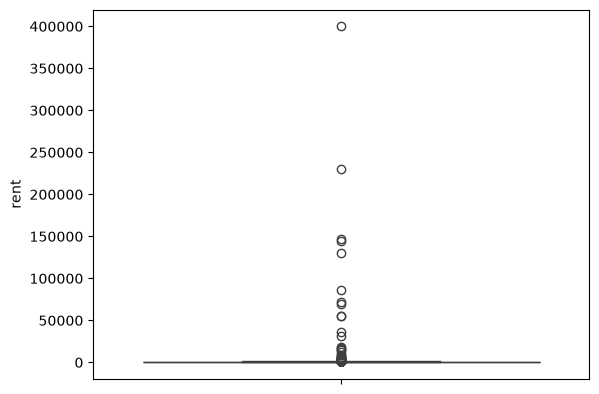

In [22]:
sns.boxplot(rental_copy['rent'])

In [23]:
rental_copy = rental_copy[rental_copy['rent'] <= 20000]
print("Rows remaining:", rental_copy.shape[0])

Rows remaining: 10562


In [24]:
rental_copy.describe()

,Property_id,Beds,Baths,Amenities,rent,has_maid,Size_sqm,is_inclusive,is_furnished,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
count,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000,10562.000000
mean,7056.332229,2.201761,2.662469,10.342075,581.711040,0.210756,171.197785,0.613047,0.186612,0.153853,0.132456,0.139841,0.188222,0.004923,0.073850,0.063246,0.034179,0.056239,0.028972
std,4078.980040,1.205480,1.288353,5.020204,527.721166,0.407864,204.984176,0.487076,0.389618,0.360825,0.339002,0.346838,0.390908,0.069997,0.261538,0.243416,0.181698,0.230394,0.167735
min,2.000000,0.000000,1.000000,1.000000,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3519.500000,1.000000,2.000000,7.000000,330.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7017.500000,2.000000,2.000000,11.000000,450.000000,0.000000,125.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10595.500000,3.000000,3.000000,14.000000,700.000000,0.000000,180.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14103.000000,7.000000,7.000000,25.000000,18000.000000,1.000000,13742.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
rental_copy[rental_copy['Size_sqm'] < 30]

,Property_id,Property_type,Area,Governorate,Beds,Baths,Agent_name,Agency,Amenities,rent,...,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
29,11528,Apartment,"Adliya, Manama",Capital Governorate,2,2.0,Brunilda Rrapa,BR Properties,7.0,370.0,...,0,0,0,0,0,0,0,0,0,0
68,9660,Compound,Saar,Northern Governorate,3,3.0,Brunilda Rrapa,BR Properties,6.0,650.0,...,0,0,0,0,0,0,0,0,0,0
189,9368,Compound,"Adliya, Manama",Capital Governorate,3,3.0,Brunilda Rrapa,BR Properties,5.0,850.0,...,0,1,0,0,0,1,0,0,0,0
283,13669,Apartment,Manama,Capital Governorate,1,1.0,s.hasan almosawi,Grnata,11.0,145.0,...,0,0,0,0,0,0,0,0,0,0
310,10325,Compound,Janabiya,Northern Governorate,4,4.0,Brunilda Rrapa,BR Properties,10.0,1200.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10048,14022,Apartment,Seef,Capital Governorate,2,2.0,Brunilda Rrapa,BR Properties,11.0,530.0,...,0,0,0,0,0,0,0,0,0,0
10093,10894,Apartment,Saar,Northern Governorate,3,2.0,Brunilda Rrapa,BR Properties,6.0,450.0,...,1,0,0,0,0,0,0,0,0,0
10145,14079,Apartment,Al Juffair,Capital Governorate,2,3.0,Brunilda Rrapa,BR Properties,5.0,400.0,...,0,0,0,0,0,0,0,0,0,0
10164,10717,Apartment,Hidd,Muharraq Governorate,1,2.0,Brunilda Rrapa,BR Properties,5.0,330.0,...,0,0,1,0,0,0,0,0,0,0


In [26]:
rental_copy = rental_copy[rental_copy['Size_sqm'] >= 20]

In [27]:
rental_copy.describe()

,Property_id,Beds,Baths,Amenities,rent,has_maid,Size_sqm,is_inclusive,is_furnished,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
count,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000,10445.000000
mean,7020.226137,2.197128,2.663475,10.372523,581.348684,0.209957,173.100048,0.617329,0.187745,0.153854,0.132791,0.141024,0.188511,0.004787,0.073528,0.063571,0.034275,0.056869,0.029296
std,4070.618998,1.204848,1.290900,5.027819,529.261554,0.407297,205.335065,0.486062,0.390527,0.360826,0.339365,0.348063,0.391139,0.069026,0.261014,0.243999,0.181943,0.231604,0.168644
min,2.000000,0.000000,1.000000,1.000000,50.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3494.000000,1.000000,2.000000,7.000000,330.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6961.000000,2.000000,2.000000,11.000000,450.000000,0.000000,125.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10559.000000,3.000000,3.000000,14.000000,700.000000,0.000000,180.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14103.000000,7.000000,7.000000,25.000000,18000.000000,1.000000,13742.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
rental_copy[rental_copy['Size_sqm'] > 2000]

,Property_id,Property_type,Area,Governorate,Beds,Baths,Agent_name,Agency,Amenities,rent,...,is_luxury,has_pool,has_sea_view,is_spacious,is_standalone,is_private,has_garden,is_compound,has_maids,is_approved
364,11375,Whole Building,"Alhajiyat, Riffa",Southern Governorate,7,7.0,City Property,City Property,4.0,12000.0,...,0,0,0,0,0,0,0,0,0,0
1467,1544,Whole Building,"Adliya, Manama",Capital Governorate,7,7.0,Fatima Rahaoui,Kooheji Real Estate & Constructions,11.0,18000.0,...,0,0,0,0,0,0,0,0,0,0
1609,3432,Whole Building,Riffa,Southern Governorate,7,7.0,Mehaboob,4You Properties,1.0,5000.0,...,0,0,0,0,0,0,0,0,0,0
3030,5330,Whole Building,"Bu Kowarah, Riffa",Southern Governorate,7,7.0,Swapna Vinod,Oriend Properties,4.0,4000.0,...,0,0,0,0,0,0,0,0,0,0
9111,11486,Villa,"Adliya, Manama",Capital Governorate,6,7.0,Vinay Sharma,Skyvio Properties,8.0,5000.0,...,1,1,0,0,0,0,0,0,0,0
10386,5916,Whole Building,"Um Al Hasam, Manama",Capital Governorate,0,7.0,Lijas Ali,Underhill Real Estate,11.0,17000.0,...,0,0,0,0,0,0,0,0,0,0
10441,6185,Villa,Saar,Northern Governorate,6,7.0,Anjum Jawaid,River West Properties,9.0,1800.0,...,0,0,0,0,1,1,0,0,0,0


<Axes: ylabel='Size_sqm'>

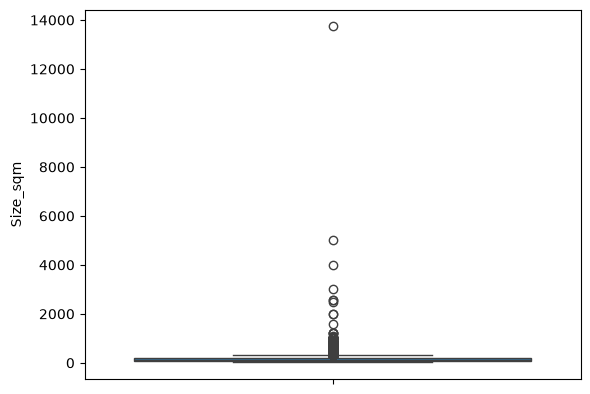

In [29]:
sns.boxplot(rental_copy['Size_sqm'])

Kept range: 40.0 - 700.0 sqm
Rows remaining: 10266


<Axes: ylabel='Size_sqm'>

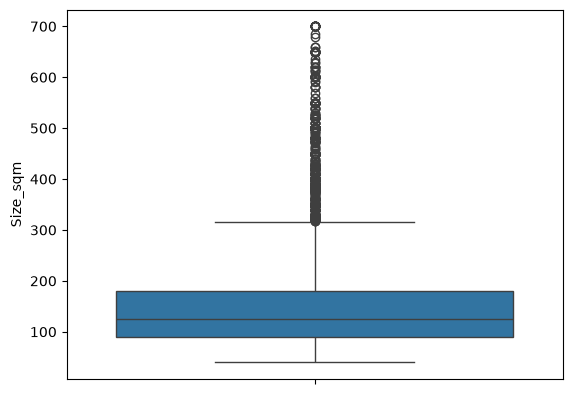

In [30]:
Q1 = rental_copy['Size_sqm'].quantile(0.01)
Q3 = rental_copy['Size_sqm'].quantile(0.99)

rental_copy = rental_copy[(rental_copy['Size_sqm'] >= Q1) & (rental_copy['Size_sqm'] <= Q3)]

print(f"Kept range: {Q1} - {Q3} sqm")
print("Rows remaining:", len(rental_copy))

sns.boxplot(rental_copy['Size_sqm'])

In [31]:
rental_copy['Size_sqm'] = np.log1p(rental_copy['Size_sqm'])
print("Size skew:", round(rental_copy['Size_sqm'].skew(), 2))

Size skew: 0.53


In [32]:
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 
    results = []
    for i in df.select_dtypes(include='number').columns:
        skew = df[i].skew()
        if -0.5 < skew < 0.5:
            degree = 'Approximately Symmetric'
        elif -1 < skew < 1:
            degree = 'moderately skewed'
        else:
            degree = 'highly skewed'

        if skew > 0:
            direction = 'positive'
        elif skew < 0:
            direction = 'negative'
        else:
            direction = 'Symmetric'

        if -0.5 < skew < 0.5:
            transform = 'None needed'
        elif df[i].min() == 0:
            transform = 'log plus one or yeo-johnson'
        elif df[i].min() < 0:
            transform = 'yeo-johnson'
        else:
            transform = 'box-cox or yeo-johnson'

        results.append({
            'Feature': i,
            'Skewness': skew,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': transform})
    return pd.DataFrame(results)

In [33]:
skew_calc(rental_copy)

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Property_id,0.016443,Approximately Symmetric,positive,None needed
1,Beds,0.592928,moderately skewed,positive,log plus one or yeo-johnson
2,Baths,0.950313,moderately skewed,positive,box-cox or yeo-johnson
3,Amenities,-0.045443,Approximately Symmetric,negative,None needed
4,rent,7.918148,highly skewed,positive,box-cox or yeo-johnson
5,has_maid,1.442227,highly skewed,positive,log plus one or yeo-johnson
6,Size_sqm,0.532918,moderately skewed,positive,box-cox or yeo-johnson
7,is_inclusive,-0.494132,Approximately Symmetric,negative,None needed
8,is_furnished,1.591619,highly skewed,positive,log plus one or yeo-johnson
9,is_luxury,1.916377,highly skewed,positive,log plus one or yeo-johnson


In [34]:
X = rental_copy.drop(columns=['rent', 'Property_id'])
y = np.log1p(rental_copy['rent'])

numeric_cols = ['Beds','Baths','Size_sqm','Amenities','has_maid','is_inclusive',
                'is_furnished','is_luxury','has_pool','has_sea_view','is_spacious',
                'is_standalone','is_private','has_garden','is_compound','has_maids','is_approved']
categorical_cols = ['Property_type','Governorate','Area','Agency']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('pow', PowerTransformer())]), numeric_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))]), categorical_cols)
])

pipe = Pipeline([('preprocessor', preprocessor), ('model', Ridge(alpha=0.5))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)

mae = mean_absolute_error(np.expm1(y_test), np.expm1(pipe.predict(X_test)))
print(f"MAE: {mae:.2f} BHD")

MAE: 102.35 BHD


In [35]:
raw = pd.read_csv('./data/data.csv')
rare_areas = raw['Area'].value_counts()[lambda s: s < 20].index
rare_agencies = raw['Agency'].value_counts()[lambda s: s < 30].index

In [36]:
pipe.fit(X, y)

test = pd.read_csv('./data/test.csv')
test_ids = test['Property_id']

# Beds
test['has_maid'] = test['Beds'].str.contains('Maid', case=False, na=False).astype(int)
test['Beds'] = (test['Beds'].str.replace('Maid', '', case=False)
                            .str.replace('+', '', regex=False)
                            .str.strip()
                            .replace('studio', '0'))
test['Beds'] = pd.to_numeric(test['Beds'], errors='coerce')

# Baths
test['Baths'] = test['Baths'].str.replace('+', '', regex=False).replace('none', np.nan)
test['Baths'] = pd.to_numeric(test['Baths'], errors='coerce')

# Size
test['Size_sqm'] = (test['Size'].str.split('/').str[-1]
                                .str.replace('sqm', '', case=False)
                                .str.replace(',', ''))
test['Size_sqm'] = pd.to_numeric(test['Size_sqm'], errors='coerce')
test['Size_sqm'] = np.log1p(test['Size_sqm'])

# Binary
test['is_inclusive'] = (test['Include_w_e'] == 'Inclusive').astype(int)

# Title keywords
t = test['Title'].fillna('').str.lower()
test['is_furnished'] = t.str.contains('furnish').astype(int)
test['is_luxury']    = t.str.contains('luxury|luxurious').astype(int)
test['has_pool']     = t.str.contains('pool').astype(int)
test['has_sea_view'] = t.str.contains('sea view|sea-view|seaview').astype(int)
test['is_spacious']  = t.str.contains('spacious|large').astype(int)
test['is_standalone'] = t.str.contains('standalone', na=False).astype(int)
test['is_private']   = t.str.contains('private|pvt', na=False).astype(int)
test['has_garden']   = t.str.contains('garden', na=False).astype(int)
test['is_compound']  = t.str.contains('compound', na=False).astype(int)
test['has_maids']    = t.str.contains('maids|maid', na=False).astype(int)
test['is_approved']  = t.str.contains('approved|navy', na=False).astype(int)

# Amenities
test['Amenities'] = test['Amenities'].fillna(test['Amenities'].median())

# Group using TRAINING lists
test['Area'] = test['Area'].replace(rare_areas, 'Other')
test['Agency'] = test['Agency'].replace(rare_agencies, 'Other')

test_final = test[X.columns]

y_pred_final = np.expm1(pipe.predict(test_final))

submission = pd.DataFrame({
    'Property_id': test_ids,
    'Rent': y_pred_final
})
submission.to_csv('submission_1212.csv', index=False)
print(submission.head())
print("Rows:", len(submission))

   Property_id        Rent
0         4394  453.783893
1         2338  681.929675
2         8531  657.384494
3         8952  357.675312
4        11064  250.083649
Rows: 3527


In [37]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(pipe_rf.predict(X_test)))
print(f"Random Forest MAE: {mae:.2f} BHD")

Random Forest MAE: 96.76 BHD


In [38]:
pipe_rf.fit(X, y)  # retrain on ALL training data

test_final = test[X.columns]
y_pred_final = np.expm1(pipe_rf.predict(test_final))

submission = pd.DataFrame({
    'Property_id': test_ids,
    'Rent': y_pred_final
})
submission.to_csv('submission_rf.csv', index=False)
print(submission.head())
print("Rows:", len(submission))

   Property_id        Rent
0         4394  459.048117
1         2338  728.365996
2         8531  590.230610
3         8952  417.600546
4        11064  290.457319
Rows: 3527


In [39]:
pipe_rf_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])

pipe_rf_2.fit(X_train, y_train)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(pipe_rf_2.predict(X_test)))
print(f"Random Forest MAE: {mae:.2f} BHD")

Random Forest MAE: 97.14 BHD


In [40]:
pipe_rf_2.fit(X, y)  

test_final = test[X.columns]
y_pred_final = np.expm1(pipe_rf_2.predict(test_final))

submission = pd.DataFrame({
    'Property_id': test_ids,
    'Rent': y_pred_final
})
submission.to_csv('submission_rf2.csv', index=False)
print(submission.head())
print("Rows:", len(submission))

   Property_id        Rent
0         4394  461.136016
1         2338  725.092502
2         8531  625.208914
3         8952  413.091212
4        11064  288.589174
Rows: 3527
